# Knowledge Graph RAG

<img src="./media/graph_start.png" width=600>

*[Improving Knowledge Graph Completion with Generative LM and neighbors](https://deeppavlov.ai/research/tpost/bn15u1y4v1-improving-knowledge-graph-completion-wit)*

In the evolving landscape of AI and information retrieval, knowledge graphs have emerged as a powerful way to represent complex, interconnected information. A knowledge graph is a knowledge base that uses a graph-structured data model or topology to represent and operate on data. Knowledge graphs are often used to store interlinked descriptions of entities – objects, events, situations or abstract concepts – while also encoding the free-form semantics or relationships underlying these entities. [Source: Wikipedia](https://en.wikipedia.org/wiki/Knowledge_graph)

What makes knowledge graphs particularly powerful is their ability to mirror human cognition in data. They more explicitly map the relationships between objects, concepts, or ideas together through both their semantic and relational connections. This approach closely parallels how our brains naturally understand and internalize information – not as isolated facts, but as a web of interconnected concepts and relationships.

<img src="./media/coffee_graph_ex.png" width=400>

Looking at a concept like "coffee," we don't just know it's a beverage; we automatically connect it to related concepts like beans, brewing methods, caffeine, morning routines, and social interactions. Knowledge graphs capture these natural associations in a structured way.

Traditional RAG systems, while effective at semantic similarity-based retrieval, often struggle to capture broader conceptual relationships across text chunks. Knowledge Graph RAG addresses this limitation by introducing a structured, hierarchical approach to information organization and retrieval. By representing data in a graph format, these systems can traverse relationships between concepts, enabling more sophisticated query understanding and response generation. This approach allows for targeted querying along specific relationship paths, handles complex multi-hop questions, and provides clearer reasoning through explicit connection paths. The result is a more nuanced and interpretable system that combines the structured reasoning of knowledge graphs with the natural language capabilities of large language models.

While [knowledge graphs are not a new concept](https://blog.google/products/search/introducing-knowledge-graph-things-not/), their creation has traditionally been a resource-intensive process. Early knowledge graphs were built either through manual curation by domain experts or by converting existing structured data from relational databases. This limited both their scale and adaptability to new domains.

<img src="./media/table_comp.png" width=600>

*[What is a Knowledge Graph (KG)?](https://zilliz.com/learn/what-is-knowledge-graph)*

The introduction of LLMs has transformed this landscape. LLMs' capabilities in NLP, reasoning, and relationship extraction now enable automated construction of knowledge graphs from unstructured text. These models can identify entities, infer relationships, and structure information in ways that previously required extensive manual labor. As a plus, this allows knowledge graphs to be dynamically updated and expanded as new information becomes available, making them more practical and scalable for real-world applications.

To see this in action ourselves, and compare it to traditional vector similarity techniques, we'll take a look at Microsoft's Open Source [GraphRAG](https://microsoft.github.io/graphrag/) and how it works behind the scenes.

---
## 3 Main Components of Knowledge Graphs

**Entity**

<img src="./media/entities.png" width=500>

An Entity is a distinct object, person, place, event, or concept that has been extracted from a chunk of text through LLM analysis. Entities form the nodes of the knowledge graph. During the creation of the knowledge graph, when duplicate entities are found they are merged while preserving their various descriptions, creating a comprehensive representation of each unique entity.

**Relationship**

<img src="./media/relationship.png" width=400>

A Relationship defines a connection between two entities in the knowledge graph. These connections are extracted directly from text units through LLM analysis, alongside entities. Each relationship includes a source entity, target entity, and descriptive information about their connection. When duplicate relationships are found between the same entities, they are merged by combining their descriptions to create a more complete understanding of the connection.

**Community**

<img src="./media/communities.png" width=400>

A Community is a cluster of related entities and relationships identified through hierarchical community detection, generally using the [Leiden Algorithm](https://en.wikipedia.org/wiki/Leiden_algorithm). Communities create a structured way to understand different levels of granularity within the knowledge graph, from broad overviews at the top level to detailed local clusters at lower levels. This hierarchical structure helps in organizing and navigating complex knowledge graphs.

---
## GraphRAG Creation Data Flow

<img src=./media/graph_building.png width=1000>

Indexxing in GraphRAG is an extensive process, where we load the document, split it into chunks, create sub graphs at a chunk level, combine these subgraphs into our final graph, algorithmically identify communities, then document the communities main features.

### **Loading and Splitting Our Text**

For our example, we'll be using [KONSUMENT NA RYNKU
BANKOWOŚCI MOBILNEJ W POLSCE PODOBIEŃSTWA I RÓŻNICE MIĘDZYPOKOLENIOWE](https://wydawnictwo.ue.poznan.pl/books/978-83-8211-157-6/978-83-8211-157-6.pdf).

This will be loaded as a text file (remove index, glossary, and references) and split into 1200 token, 100 token overlap chunks.

In [2]:
import fitz
import os

def convert_all_pdfs_in_folder(input_folder, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(input_folder):
        if filename.lower().endswith(".pdf"):
            pdf_path = os.path.join(input_folder, filename)
            txt_filename = filename.rsplit(".", 1)[0] + ".txt"
            txt_path = os.path.join(output_folder, txt_filename)

            doc = fitz.open(pdf_path)
            with open(txt_path, "w", encoding="utf-8") as txt_file:
                for page in doc:
                    txt_file.write(page.get_text())
            print(f"Przekonwertowano: {filename} → {txt_filename}")

convert_all_pdfs_in_folder("ragtest/input", "ragtest/input")

Przekonwertowano: Konsument_na_rynku_bankowości_mobilnej_w_Polsce.pdf → Konsument_na_rynku_bankowości_mobilnej_w_Polsce.txt


In [2]:
from langchain_text_splitters import TokenTextSplitter

with open(r".\ragtest\input\Konsument_na_rynku_bankowości_mobilnej_w_Polsce.txt", 'r', encoding='utf-8') as file:
    content = file.read()

text_splitter = TokenTextSplitter(chunk_size=1200, chunk_overlap=100)
texts = text_splitter.split_text(content)

In [3]:
len(texts)

133

<img src=./media/ss1.png width=1000>

**Entity and Relationship Extraction Prompt**

This is a [tuned](https://microsoft.github.io/graphrag/prompt_tuning/auto_prompt_tuning/) entity extraction prompt used in our real GraphRAG implementation, extracted in this format to see what's happening.

In [25]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(temperature=0.0, model="gpt-4o")

prompt_template = """
-Cel-
Na podstawie dostarczonego tekstu dotyczącego bankowości mobilnej oraz listy typów encji, zidentyfikuj wszystkie encje należące do tych typów oraz relacje między nimi.

-Kroki-
1. Zidentyfikuj wszystkie encje. Dla każdej z nich podaj:
- entity_name: Nazwa encji, pisana wielkimi literami
- entity_type: Jeden z następujących typów: [aplikacja bankowa, system płatności, zachowanie użytkownika, środek bezpieczeństwa, kohorta pokoleniowa, usługa finansowa, model akceptacji technologii, źródło danych statystycznych, metoda płatności mobilnej, profil użytkownika, portfel cyfrowy, płatność zbliżeniowa, instytucja finansowa, usługa bankowości mobilnej, typ transakcji, doświadczenie użytkownika, umiejętności cyfrowe, ramy regulacyjne, urządzenie mobilne, metoda uwierzytelniania]
- entity_description: Szczegółowy opis cech i działań encji
Sformatuj każdą encję jako ("entity"{{tuple_delimiter}}<entity_name>{{tuple_delimiter}}<entity_type>{{tuple_delimiter}}<entity_description>)

2. Na podstawie zidentyfikowanych encji, określ wszystkie pary (source_entity, target_entity), które są ze sobą wyraźnie powiązane.
Dla każdej pary podaj:
- source_entity: nazwa encji źródłowej
- target_entity: nazwa encji docelowej
- relationship_description: wyjaśnienie, dlaczego uważasz, że te encje są powiązane
- relationship_strength: liczba całkowita od 1 do 10, wskazująca na siłę relacji między encjami
Sformatuj każdą relację jako ("relationship"{{tuple_delimiter}}<source_entity>{{tuple_delimiter}}<target_entity>{{tuple_delimiter}}<relationship_description>{{tuple_delimiter}}<relationship_strength>)

3. Zwróć wynik w języku polskim jako pojedynczą listę wszystkich zidentyfikowanych encji i relacji z kroków 1 i 2. Użyj **{{record_delimiter}}** jako separatora listy.

4. Jeśli musisz przetłumaczyć na język polski, przetłumacz tylko opisy, nic więcej!

5. Po zakończeniu, wyświetl {{completion_delimiter}}.

-Przykłady-
######################

Przykład:

entity_types: [aplikacja bankowa, system płatności, zachowanie użytkownika, środek bezpieczeństwa, kohorta pokoleniowa, usługa finansowa, model akceptacji technologii, źródło danych statystycznych, metoda płatności mobilnej, profil użytkownika, portfel cyfrowy, płatność zbliżeniowa, instytucja finansowa, usługa bankowości mobilnej, typ transakcji, doświadczenie użytkownika, umiejętności cyfrowe, ramy regulacyjne, urządzenie mobilne, metoda uwierzytelniania]
text:
Aplikacje mobilne banków stają się coraz bardziej popularne wśród klientów indywidualnych. System BLIK umożliwia szybkie płatności bezgotówkowe. Pokolenie Y wykazuje wysoką akceptację technologii mobilnych, co wpływa na częstsze korzystanie z usług bankowości mobilnej. Badania GUS pokazują rosnący trend w korzystaniu z aplikacji mobilnych do zarządzania finansami osobistymi.
------------------------
output:
("entity"{{tuple_delimiter}}APLIKACJE MOBILNE BANKÓW{{tuple_delimiter}}aplikacja bankowa{{tuple_delimiter}}Aplikacje mobilne oferowane przez banki umożliwiają klientom indywidualnym dostęp do usług finansowych za pomocą urządzeń mobilnych.{{record_delimiter}}
("entity"{{tuple_delimiter}}SYSTEM BLIK{{tuple_delimiter}}system płatności{{tuple_delimiter}}BLIK to polski system płatności mobilnych umożliwiający szybkie i bezpieczne transakcje bezgotówkowe.{{record_delimiter}}
("entity"{{tuple_delimiter}}POKOLENIE Y{{tuple_delimiter}}kohorta pokoleniowa{{tuple_delimiter}}Pokolenie Y, znane również jako millenialsi, charakteryzuje się wysoką akceptacją technologii mobilnych i częstym korzystaniem z aplikacji bankowych.{{record_delimiter}}
("entity"{{tuple_delimiter}}GUS{{tuple_delimiter}}źródło danych statystycznych{{tuple_delimiter}}Główny Urząd Statystyczny (GUS) dostarcza danych statystycznych dotyczących różnych aspektów życia społeczno-gospodarczego, w tym korzystania z usług bankowych.{{record_delimiter}}
("relationship"{{tuple_delimiter}}APLIKACJE MOBILNE BANKÓW{{tuple_delimiter}}POKOLENIE Y{{tuple_delimiter}}Pokolenie Y wykazuje wysoką akceptację aplikacji mobilnych banków, co przekłada się na częstsze korzystanie z tych usług.{{tuple_delimiter}}9{{record_delimiter}}
("relationship"{{tuple_delimiter}}SYSTEM BLIK{{tuple_delimiter}}APLIKACJE MOBILNE BANKÓW{{tuple_delimiter}}System BLIK jest zintegrowany z aplikacjami mobilnymi banków, umożliwiając użytkownikom dokonywanie szybkich płatności.{{tuple_delimiter}}8{{record_delimiter}}
("relationship"{{tuple_delimiter}}GUS{{tuple_delimiter}}APLIKACJE MOBILNE BANKÓW{{tuple_delimiter}}GUS dostarcza danych statystycznych na temat korzystania z aplikacji mobilnych banków przez klientów indywidualnych.{{tuple_delimiter}}7{{completion_delimiter}}
#############################

-Dane rzeczywiste-
######################
entity_types: [aplikacja bankowa, system płatności, zachowanie użytkownika, środek bezpieczeństwa, kohorta pokoleniowa, usługa finansowa, model akceptacji technologii, źródło danych statystycznych, metoda płatności mobilnej, profil użytkownika, portfel cyfrowy, płatność zbliżeniowa, instytucja finansowa, usługa bankowości mobilnej, typ transakcji, doświadczenie użytkownika, umiejętności cyfrowe, ramy regulacyjne, urządzenie mobilne, metoda uwierzytelniania]
text: {input_text}
######################
output:
"""

prompt = ChatPromptTemplate.from_template(prompt_template)

chain = prompt | llm | StrOutputParser()


**Creating a Response**

In [9]:
response = chain.invoke({"input_text": texts[25]})

In [10]:
print(response)

("entity"{tuple_delimiter}BANKOWOŚĆ MOBILNA{tuple_delimiter}usługa bankowości mobilnej{tuple_delimiter}Usługa umożliwiająca klientom banków dokonywanie transakcji i zarządzanie finansami za pomocą urządzeń mobilnych.{record_delimiter}
("entity"{tuple_delimiter}PŁATNOŚCI MOBILNE{tuple_delimiter}metoda płatności mobilnej{tuple_delimiter}Metoda płatności, która pozwala użytkownikom na dokonywanie transakcji finansowych za pomocą urządzeń mobilnych.{record_delimiter}
("entity"{tuple_delimiter}OSOBY STARSZE{tuple_delimiter}profil użytkownika{tuple_delimiter}Grupa użytkowników w wieku 60 lat i więcej, która wykazuje niechęć do korzystania z płatności mobilnych z powodu barier funkcjonalnych, psychologicznych i ryzyka.{record_delimiter}
("entity"{tuple_delimiter}PRZYJEMNOŚĆ UŻYTKOWANIA{tuple_delimiter}doświadczenie użytkownika{tuple_delimiter}Czynnik wpływający na intencję korzystania z bankowości mobilnej, szczególnie wśród młodszych klientów.{record_delimiter}
("entity"{tuple_delimiter}UMIE

We see the extraction of **entities**:

`("entity"{tuple_delimiter}EVALUATION METRICS{tuple_delimiter}evaluation metrics{tuple_delimiter}Evaluation metrics are criteria  used to assess the performance of AI models, including metrics like cross-entropy, perplexity, factuality, and context relevance)`

As well as **relationships**:

`("relationship"{tuple_delimiter}EVALUATION METRICS{tuple_delimiter}CONTEXT RELEVANCE{tuple_delimiter}Context relevance is an evaluation metric that ensures the model uses the most pertinent information for generating responses{tuple_delimiter}8)`

Following this, these per chunk subgraphs are merged together - any entities with the same name and type are merged by creating an array of their descriptions. Similarly, any relationships with the same source and target are merged by creating an array of their descriptions. These lists are then summarized one more time 

### **Looking at Final Entities and Relationships**

In [4]:
import pandas as pd

entities = pd.read_parquet('./ragtest/output/entities.parquet')

entities.head()

,id,human_readable_id,title,type,description,text_unit_ids,frequency,degree,x,y
0,872b3fe1-639f-4f75-99cd-26a65c48d32e,0,PRNEWS.PL,ORGANIZATION,PRNews.pl is a prominent Polish news portal sp...,[5ce3dcc5373de08100ec2648ad9e2256d4cd47e876148...,12,12,0.0,0.0
1,cefddfa9-b153-4d2c-aa47-1389ca11927f,1,POLAND,GEO,"Poland, a country located in Central Europe, h...",[5ce3dcc5373de08100ec2648ad9e2256d4cd47e876148...,24,85,0.0,0.0
2,7ac308ad-ab97-4151-9c95-5989d467b9f2,2,BOCZOŃ,PERSON,Boczoń is the author of the data analysis on t...,[5ce3dcc5373de08100ec2648ad9e2256d4cd47e876148...,1,1,0.0,0.0
3,54ce9104-4ff7-422e-9194-89ee979b4f42,3,GENERATION Z,PERSON,"Generation Z, also known as ""mobile natives"" o...",[5ce3dcc5373de08100ec2648ad9e2256d4cd47e876148...,11,31,0.0,0.0
4,71f7c225-6265-4679-9577-1048dca968dd,4,GENERATION Y,PERSON,"Generation Y, also known as Millennials, is a ...",[5ce3dcc5373de08100ec2648ad9e2256d4cd47e876148...,9,26,0.0,0.0


In [5]:
relationships = pd.read_parquet('./ragtest/output/relationships.parquet')

relationships.head()

,id,human_readable_id,source,target,description,weight,combined_degree,text_unit_ids
0,17797c8d-e6f3-4f84-8761-f6e98a589d7d,0,PRNEWS.PL,POLAND,PRNews.pl is a prominent news source in Poland...,16.0,97,[5ce3dcc5373de08100ec2648ad9e2256d4cd47e876148...
1,6634dc38-3180-4583-99a9-9e7218dc80f2,1,PRNEWS.PL,BOCZOŃ,Boczoń is associated with PRNews.pl as the aut...,7.0,13,[5ce3dcc5373de08100ec2648ad9e2256d4cd47e876148...
2,fac168cb-7312-4347-a084-4733d5c5b9b9,2,GENERATION Z,GENERATION Y,Generation Z and Generation Y are both digital...,13.0,57,[5ce3dcc5373de08100ec2648ad9e2256d4cd47e876148...
3,ecb5e8cd-c157-488f-9335-a5934f7bf99d,3,GENERATION Z,GENERATION X,"Generation Z, often referred to as Gen Z, is a...",21.0,59,[5ce3dcc5373de08100ec2648ad9e2256d4cd47e876148...
4,db9b9883-6bb3-45d5-af72-f9c20101e090,4,GENERATION Y,GENERATION X,"Generation Y, also known as Millennials, and G...",2.0,54,[5ce3dcc5373de08100ec2648ad9e2256d4cd47e876148...


### **Community Detection & Node Embedding**

<img src="./media/leidan.png" width=600>

After we have our basic graph with entities and relationships, we analyze its structure in two ways. Community Detection uses the [Leiden algorithm](https://en.wikipedia.org/wiki/Leiden_algorithm) to find explicit groupings in the graph, creating a hierarchy of related entities. The lower in the hierarchy, the more granular the community. Node Embedding uses [Node2Vec](https://arxiv.org/abs/1607.00653) to create vector representations of each entity, capturing implicit relationships in the graph structure. These complementary approaches let us understand both obvious connections through communities and subtle patterns through embeddings.

Combining all of this with our relationships gives us our final nodes.

In [6]:
nodes = pd.read_parquet('./ragtest/output/communities.parquet')

nodes.head(10)

,id,human_readable_id,community,level,parent,children,title,entity_ids,relationship_ids,text_unit_ids,period,size
0,553f7e7a-b4fa-462d-b8ff-c099219e3ec4,0,0,0,-1,"[18, 19, 20, 21, 22]",Community 0,"[af065a6f-91d7-47b1-bf39-d9a16d132c9a, 24840ff...","[003fd573-15ce-44d9-a445-7f2ba0b87fcc, 01cb612...",[00015690f210ad8cae66c67e020e88d1be5ade98ac923...,2025-05-30,99
1,5f549282-8fb9-4b14-a4b4-2c5a097718c3,1,1,0,-1,"[23, 24, 25, 26]",Community 1,"[d48e8627-5e44-4f08-ae74-6985a751e3bb, fbd04a7...","[069f3a13-e554-4a8f-9680-9c9321cc67e5, 07f5fa7...",[231514245967463457e11f9a586e74887d0ad42e5f08e...,2025-05-30,37
2,886785c1-51a1-4066-a3b9-436557344ba4,2,2,0,-1,"[27, 28, 29, 30, 31]",Community 2,"[bbe05cc5-9617-487f-a587-f7cecd91a4fb, b2f85ca...","[042a3c16-9267-4c4c-9ea5-1b52eee70f33, 0bd935b...",[44589034abe0871b3c8e277f79cb09a3df592f0a2dc6b...,2025-05-30,35
3,12ab65cb-7919-4843-a6ca-8266ae065b14,3,3,0,-1,[],Community 3,"[2d99099c-3621-428d-901d-974e047696f6, 435d4ce...","[1553351c-257d-4f56-9c68-97bf518b8431, 192d165...",[54a7d048258be89d91abf7313a5f6f8871f626a3bec76...,2025-05-30,4
4,0ecef8b6-05b7-4a13-848f-c05afaf6599d,4,4,0,-1,"[32, 33, 34]",Community 4,"[ce85a088-1e99-44fd-a8c6-953ab1fd09c1, f8b8d14...","[03d3efff-7533-463d-bdd2-67afc9ca28da, 4bcdb1c...",[2c4d4370169ef54c65a9e8890e0efbd2375ba86122c81...,2025-05-30,12
5,9aebffa5-3d94-40e4-973b-2d48f2a15c2a,5,5,0,-1,"[35, 36, 37, 38, 39]",Community 5,"[f2bf5e07-6247-42b0-a1b0-a22396c29118, cb87ebf...","[047255ce-be18-42fd-8bf0-48aed2d455ab, 04d382e...",[12a8eca7fc096aa59f05d8a96840e8bc9099c1daadc6e...,2025-05-30,39
6,4d4e5d28-260c-4809-8149-b2793ece1326,6,6,0,-1,"[40, 41]",Community 6,"[3cbe2af9-231d-4476-b7a2-0610d9c190ec, 27d4282...","[030469bd-4e32-47e1-a031-3f25c6edd97a, 04ce942...",[3cd136722e987d87e3202a5dac9bce38c72606808377e...,2025-05-30,18
7,c92b47b6-651e-4a9d-86f2-69ec8d139044,7,7,0,-1,[],Community 7,"[56aa90b4-12ff-46a1-8929-237b9857da25, 8495aba...","[1487aabd-d09a-463b-85d4-690566c1913f, 44e9fa3...",[78481ce353f97b5093cdebb0746681a036f5ad2d9da6c...,2025-05-30,4
8,cd396af9-5d76-4f17-b684-9a7cecbb4e51,8,8,0,-1,"[42, 43]",Community 8,"[481da832-32b3-4556-a082-761c29834cff, 120513a...","[060caed4-0846-4cfb-995f-46770062ddbd, 0903bd2...",[7009011582b9ec4e53a5c653862e1aeb20c86cee40167...,2025-05-30,13
9,bb6c2937-7d70-481a-8644-f4dcd6561dd0,9,9,0,-1,[],Community 9,"[cb05042b-7a05-4f64-81c2-416b6123bf28, 7c0ef20...",[6fd1ad90-7db4-4ecc-ae6f-fe2f5af7a50f],[e2aab74b761c1701a2c9e1aaae8fd98d10c538c0ae7fc...,2025-05-30,2


At this step the graph is effectively created, however we can introduce a few extra steps that will allow us to do some advanced retrieval.

### Community Report Generation & Summarization

Now that we have clear community grouping, we can aggregate the main concepts across hierarchical node communities with another generation step, and a shorthand summary of that summary. Similar to the nodes, these summaries are also ran through an embedding model and stored in a vector store.

In [7]:
community_reports = pd.read_parquet('./ragtest/output/community_reports.parquet')

community_reports.head()

,id,human_readable_id,community,level,parent,children,title,summary,full_content,rank,rating_explanation,findings,full_content_json,period,size
0,edb2e21716b848389d8c2202b3aedb95,80,80,3,78,[],Mobile Banking Security Community,The community is centered around mobile bankin...,# Mobile Banking Security Community\n\nThe com...,6.5,The impact severity rating is moderate to high...,[{'explanation': 'Mobile banking application u...,"{\n ""title"": ""Mobile Banking Security Commu...",2025-05-30,2
1,69058200947443e888f75f42d74c8587,81,81,3,78,[],Banks and Mobile Banking Security,The community is centered around banks and the...,# Banks and Mobile Banking Security\n\nThe com...,7.5,The impact severity rating is high due to the ...,[{'explanation': 'Banks are at the forefront o...,"{\n ""title"": ""Banks and Mobile Banking Secu...",2025-05-30,8
2,c4b0b17dcd2c4c7abda256d275761c44,58,58,2,18,[],BLIK Payment System and Polish Banking Institu...,The community is centered around the BLIK paym...,# BLIK Payment System and Polish Banking Insti...,8.5,The impact severity rating is high due to BLIK...,[{'explanation': 'BLIK is a prominent mobile p...,"{\n ""title"": ""BLIK Payment System and Polis...",2025-05-30,20
3,02f42cf388e3486488f857a8887d5042,59,59,2,18,[],Raiffeisen Bank Polska and Inteligo: Pioneers ...,This community is centered around two key enti...,# Raiffeisen Bank Polska and Inteligo: Pioneer...,7.5,The impact severity rating is high due to the ...,[{'explanation': 'Raiffeisen Bank Polska has b...,"{\n ""title"": ""Raiffeisen Bank Polska and In...",2025-05-30,2
4,3dba9c1451ef4a199e737a752a8b9c7a,60,60,2,18,[],Polish Mobile Banking and BLIK System,This community is centered around the developm...,# Polish Mobile Banking and BLIK System\n\nThi...,8.5,The impact severity rating is high due to the ...,[{'explanation': 'ING Bank Śląski is a promine...,"{\n ""title"": ""Polish Mobile Banking and BLI...",2025-05-30,7


In [8]:
print(community_reports["full_content"][0])

# Mobile Banking Security Community

The community is centered around mobile banking application users who are concerned about the security of their transactions. These users are connected to the concept of mobile banking security and the use of antivirus software as a means to enhance their security measures. The relationships within this community highlight the importance of security awareness and the perceived necessity of antivirus software in safeguarding mobile banking activities.

## Mobile Banking Application Users' Security Concerns

Mobile banking application users form the core of this community, with a significant focus on the security of their banking activities. These users are actively aware of potential security threats and take measures to protect their financial information. The degree of concern among users is reflected in their proactive approach to enhancing security, which is a critical aspect of their engagement with mobile banking platforms [Data: Entities (489)

In [9]:
print(community_reports["summary"][0])

The community is centered around mobile banking application users who are concerned about the security of their transactions. These users are connected to the concept of mobile banking security and the use of antivirus software as a means to enhance their security measures. The relationships within this community highlight the importance of security awareness and the perceived necessity of antivirus software in safeguarding mobile banking activities.


<img src="./media/ss2.png" width=600>


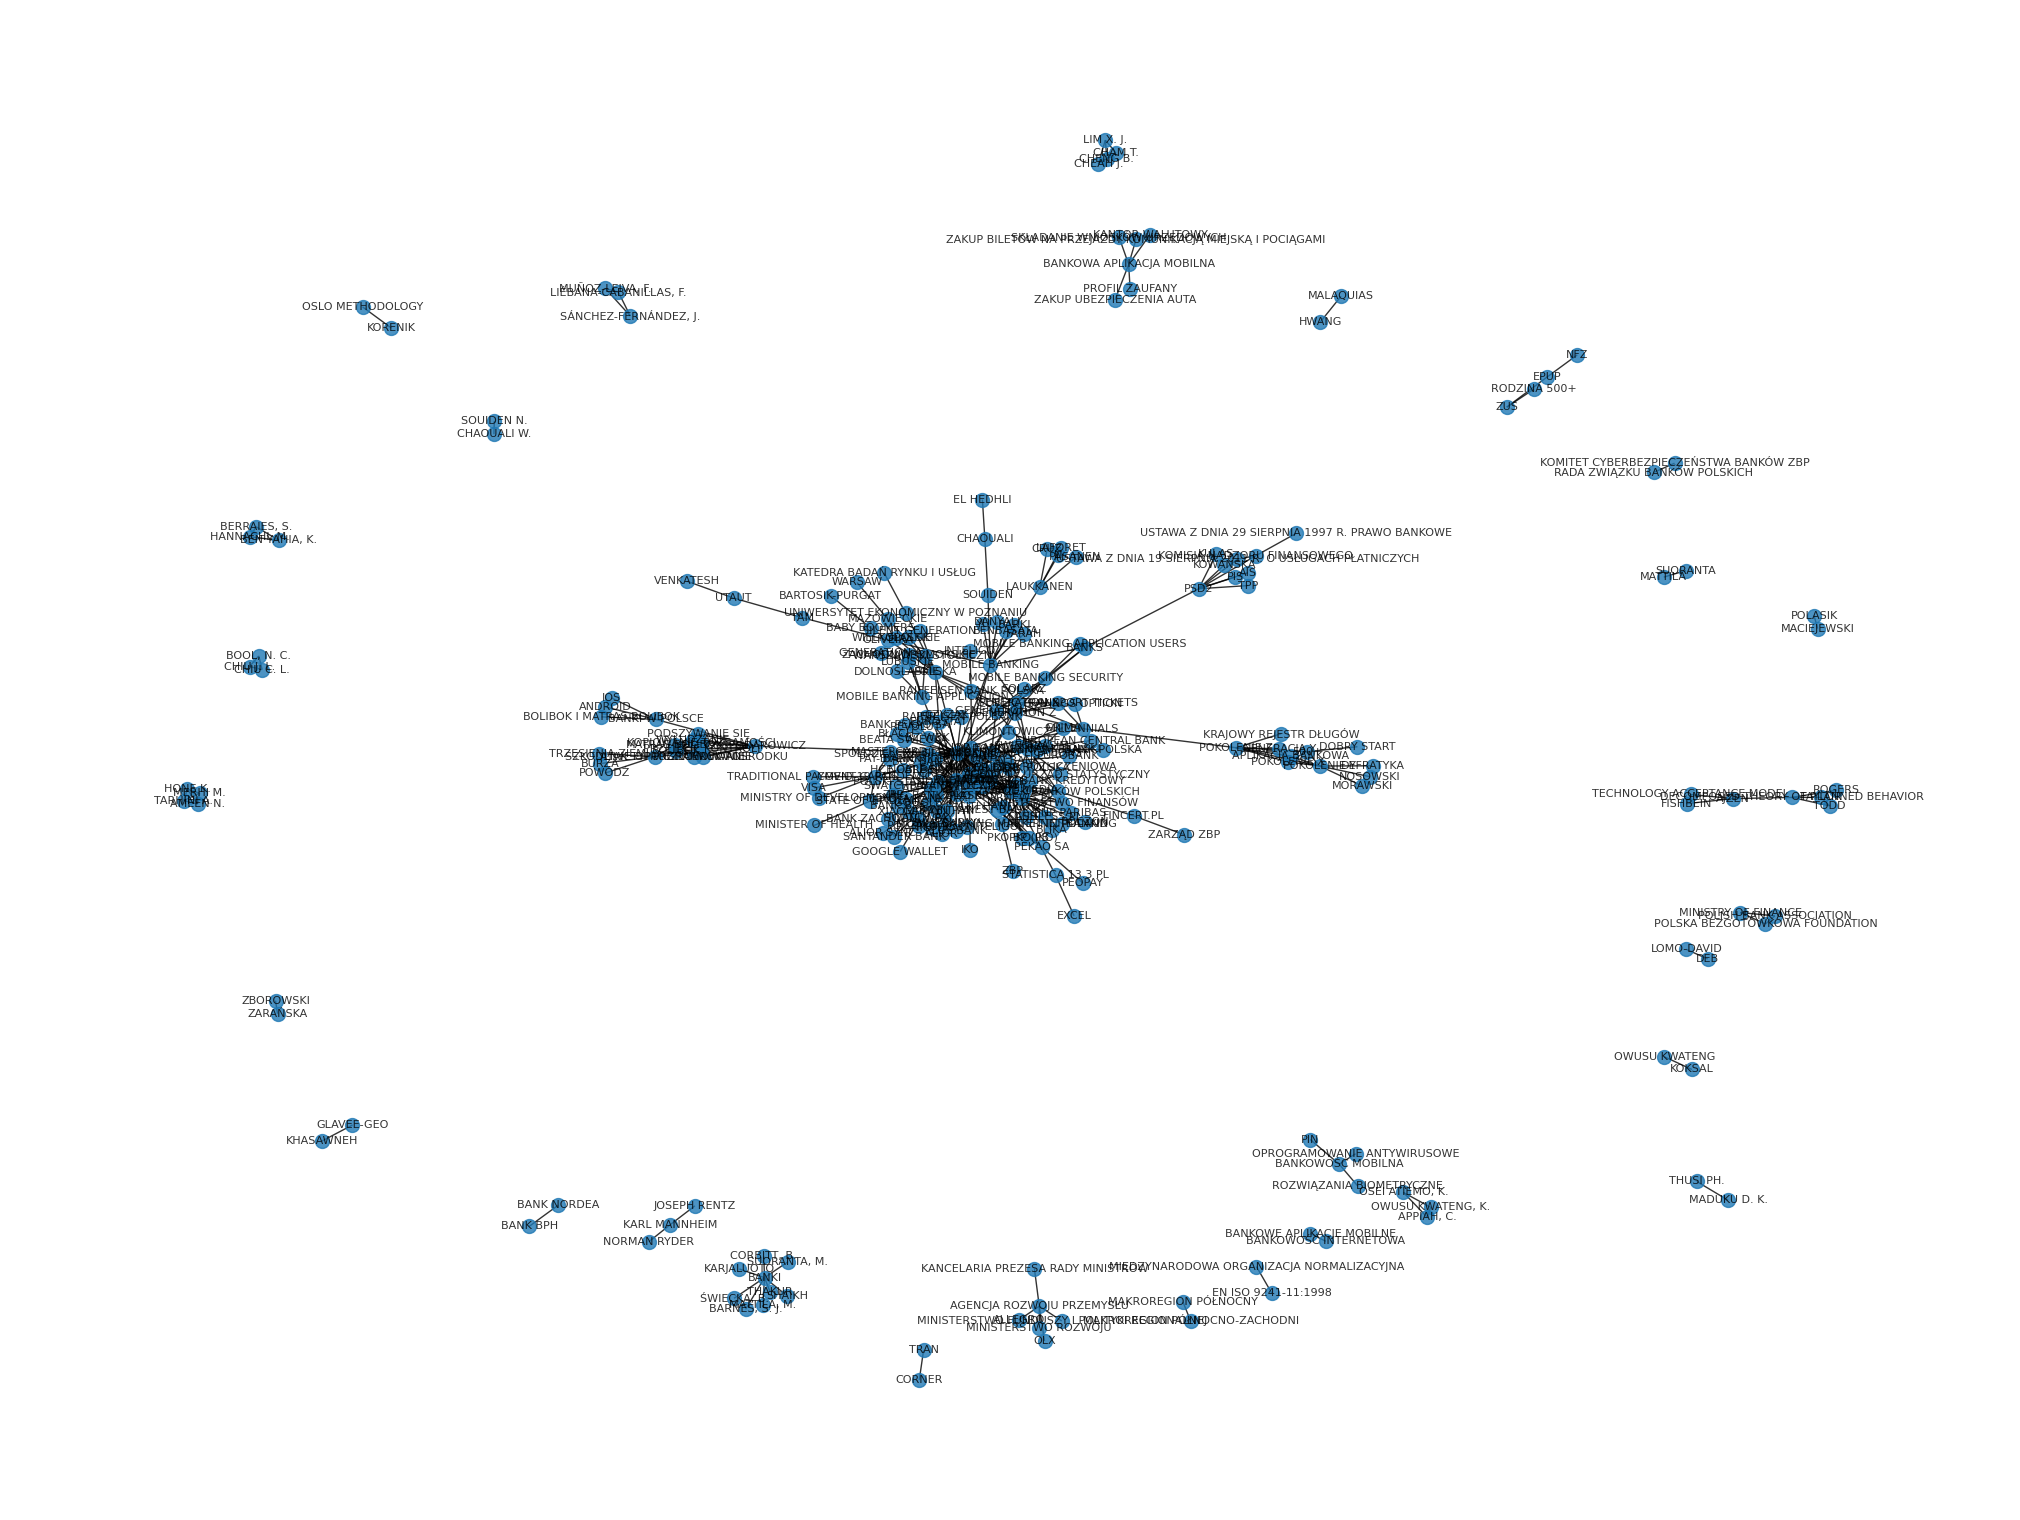

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Read Parquet
df = pd.read_parquet(r"ragtest\output\relationships.parquet")

# Example: assume df has "source" and "target" columns for edges
G = nx.from_pandas_edgelist(df, source='source', target='target')

# Layout and draw
pos = nx.spring_layout(G)
plt.figure(figsize=(20, 15))
nx.draw(G, pos, node_size=100, alpha=0.8, with_labels=True, font_size=8)

# Save as SVG or PDF
plt.savefig("graph_output.svg", format='svg')
# Or:
plt.savefig("graph_output.pdf", format='pdf')


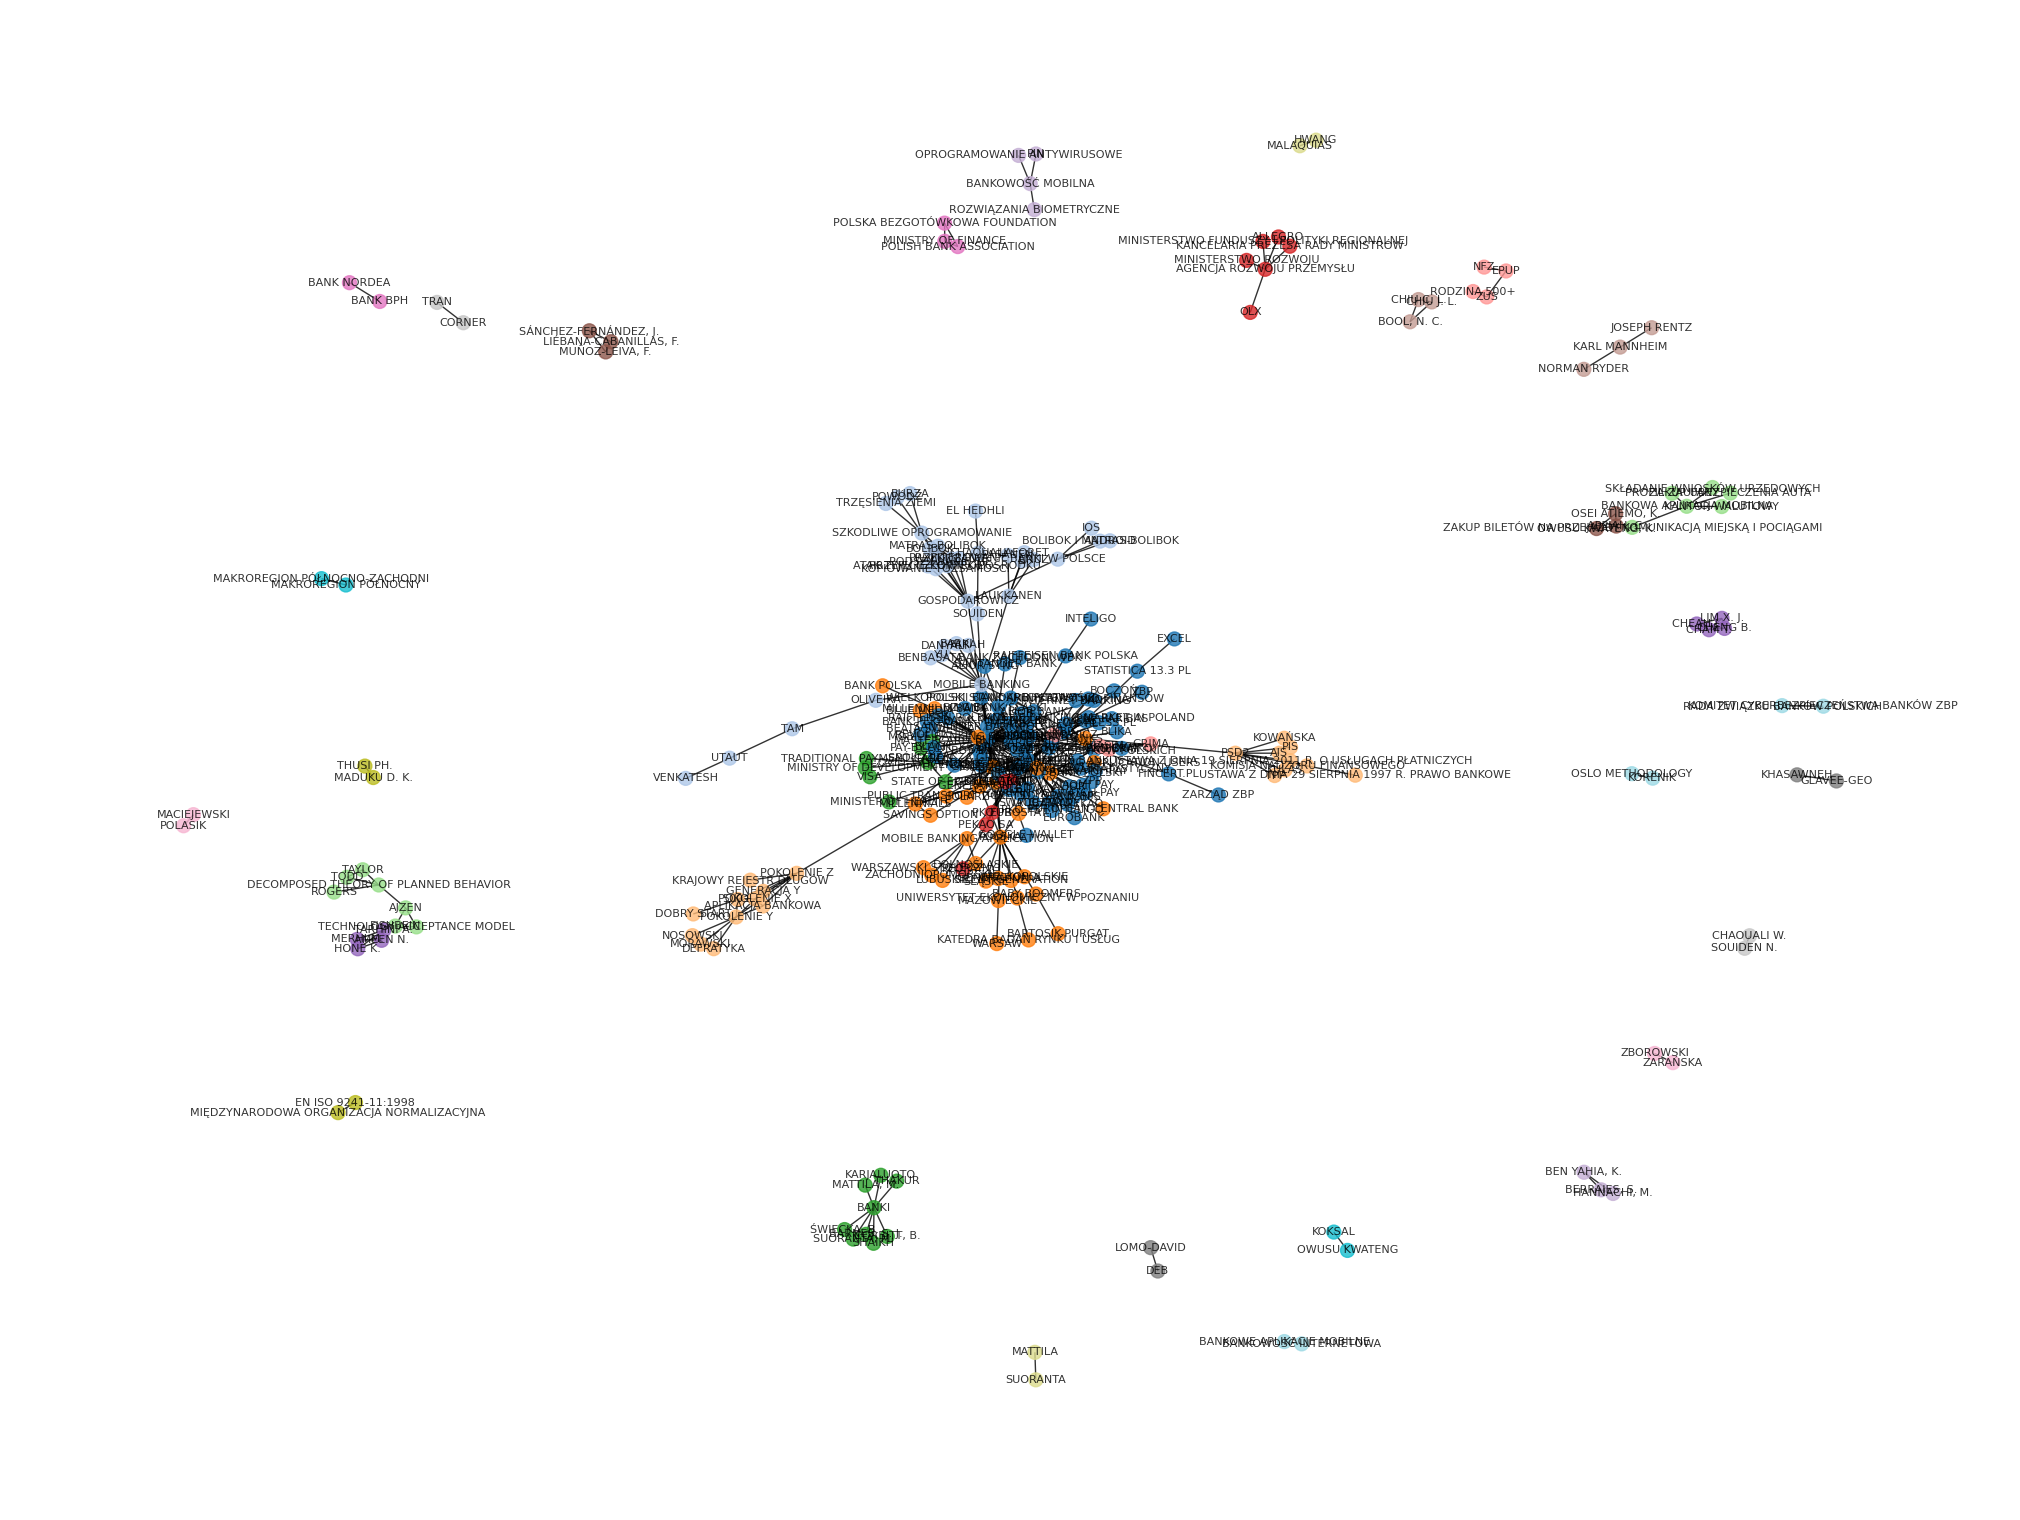

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import igraph as ig
import leidenalg
import warnings

# Wyciszenie SyntaxWarnings z leidenalg
warnings.filterwarnings("ignore", category=SyntaxWarning)

# 1. Wczytaj dane z Parquet
df = pd.read_parquet(r"ragtest\output\relationships.parquet")

# 2. Zbuduj graf NetworkX
G_nx = nx.from_pandas_edgelist(df, source='source', target='target')

# 3. Konwersja do igraph (Leiden wymaga igraph)
edges = list(G_nx.edges())
G_ig = ig.Graph.TupleList(edges, directed=False)

# 4. Wykryj społeczności metodą Leiden
leiden_partition = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition)

# 5. Mapuj węzły igraph -> społeczność
membership = {}
for community_id, community_nodes in enumerate(leiden_partition):
    for node in community_nodes:
        nx_node = G_ig.vs[node]['name']
        membership[nx_node] = community_id

# 6. Przypisz kolory do węzłów na podstawie społeczności
colors = [membership[node] for node in G_nx.nodes()]
num_comms = max(colors) + 1

# 7. Rysuj graf z kolorem dla każdej społeczności
pos = nx.spring_layout(G_nx, seed=42)
cmap = plt.colormaps.get_cmap('tab20').resampled(num_comms)

plt.figure(figsize=(20, 15))
nx.draw(
    G_nx, pos,
    node_color=colors,
    cmap=cmap,
    node_size=100,
    alpha=0.8,
    with_labels=True,
    font_size=8
)

plt.savefig("graph_output.svg", format='svg', bbox_inches='tight')
plt.savefig("graph_output.pdf", format='pdf', bbox_inches='tight')

https://noworneverev.github.io/graphrag-visualizer/#/upload

---

## GraphRAG Retrieval

<img src="./media/kg_retrieval.png" width=600>

*[Unifying Large Language Models and Knowledge Graphs: A Roadmap](https://arxiv.org/pdf/2306.08302)*

With our knowledge graph constructed, and hierarchichal communities delineated, we can now perform multiple types of search that can both take advantage of the graph structure, and multiple levels of specificity across our communities. Specifically:

1. **Global Search**: Uses the LLM Generated community reports from a specified level of the graph's community hierarchy as context data to generate response.
2. **Local Search**: Combines structured data from the knowledge graph with unstructured data from the input document(s) to augment the LLM context with relevant entity information.
3. **Drift Search**: Dynamic Reasoning and Inference with Flexible Traversal, an approach to local search queries by including community information in the search process, thus combining global and local search.

**GraphRAG Retrieval Function**

*Note: Wrapping the [GraphRAG CLI tool](https://microsoft.github.io/graphrag/cli/) as a function here instead of using their [library](https://microsoft.github.io/graphrag/examples_notebooks/api_overview/) for an easier example. As such, notebook needs to be running in the same GraphRAG environment/kernal.*

In [16]:
import subprocess
import os
from typing import Optional

def query_graphrag(
    query: str,
    method: str = "global",
    root_path: str = "./ragtest",
    timeout: Optional[int] = None,
    community_level: int = 2,
    dynamic_community_selection: bool = False
) -> str:
    """
    Execute a GraphRAG query using the CLI tool with proper Unicode handling.
    
    Args:
        query (str): The query string to process
        method (str): Query method (e.g., "global", "local", or "drift")
        root_path (str): Path to the root directory
        timeout (int, optional): Timeout in seconds for the command
        community_level (int): The community level in the Leiden community hierarchy (default: 2)
        dynamic_community_selection (bool): Whether to use global search with dynamic community selection (default: False)
        
    Returns:
        str: The output from GraphRAG
        
    Raises:
        subprocess.CalledProcessError: If the command fails
        subprocess.TimeoutExpired: If the command times out
        ValueError: If community_level is negative
    """
    # Validate community level
    if community_level < 0:
        raise ValueError("Community level must be non-negative")
        
    # Construct the base command
    command = [
        'graphrag', 'query',
        '--root', root_path,
        '--method', method,
        '--query', query,
        '--community-level', str(community_level)
    ]
    
    # Add dynamic community selection flag if enabled
    if dynamic_community_selection:
        command.append('--dynamic-community-selection')
    
    # Set up environment with proper encoding
    env = os.environ.copy()
    env['PYTHONIOENCODING'] = 'utf-8'
    env['PYTHONUTF8'] = '1'
    
    try:
        # Execute the command and capture output with explicit UTF-8 encoding
        result = subprocess.run(
            command,
            capture_output=True,
            text=True,
            encoding='utf-8',  # Explicitly use UTF-8 encoding
            errors='replace',  # Replace characters that can't be decoded
            timeout=timeout,
            env=env  # Use the environment with UTF-8 settings
        )
        
        # Check if the command was successful
        result.check_returncode()
        
        return result.stdout.strip()
        
    except subprocess.CalledProcessError as e:
        error_message = f"Command failed with exit code {e.returncode}\nError: {e.stderr}"
        raise subprocess.CalledProcessError(
            e.returncode,
            e.cmd,
            output=e.output,
            stderr=error_message
        )

### Local Search

<img src="./media/local_search.png" width=900>

The GraphRAG approach to local search is the most similar to regular semantic RAG search. It combines structured data from the knowledge graph with unstructured data from the input documents to augment the LLM context with relevant entity information. In essence, we are going to first search for relevant entities to the query using semantic search. These become the entry points on our graph that we can now traverse. Starting at these points, we look at connected chunks of text, community reports, other entities, and relationships between them. All of the data retrieved is filtered and ranked to fit into a pre-defined context window.

In [17]:
result = query_graphrag(
    query="Jakie różnice pokoleniowe występują w zakresie korzystania z funkcjonalności bankowości mobilnej i jakie czynniki technologiczne oraz społeczne je warunkują?",
    method="local"
)
print("Query result:")
print(result)

Query result:
INFO: Vector Store Args: {
    "default_vector_store": {
        "type": "lancedb",
        "db_uri": "C:\\Users\\racha\\Desktop\\PROJECTS\\grapgrag-demo\\GraphRAG-Breakdown\\ragtest\\output\\lancedb",
        "url": null,
        "audience": null,
        "container_name": "==== REDACTED ====",
        "database_name": null,
        "overwrite": true
    }
}

SUCCESS: Local Search Response:
## Różnice Pokoleniowe w Korzystaniu z Bankowości Mobilnej

W Polsce różnice pokoleniowe w korzystaniu z bankowości mobilnej są wyraźnie widoczne, szczególnie między młodszymi a starszymi generacjami. Generacja Z, czyli osoby urodzone po 1996 roku, najczęściej korzysta z aplikacji mobilnych banków, co wskazuje, że dla tej grupy mobilny kanał dostępu jest głównym sposobem realizacji usług bankowych [Data: Sources (92)]. Generacja Y, znana również jako Millenialsi, również aktywnie korzysta z bankowości mobilnej, choć w mniejszym stopniu niż Generacja Z [Data: Sources (92); Entities (31

### Global Search

<img src="./media/global_search.png" width=1000>

Through the semantic clustering of communities during the indexxing process outlined above we created community reports as summaries of high level themes across these groupings. Having this community summary data at various levels allows us to do something that traditional RAG performs poorly at, answering queries about broad themes and ideas across our unstructured data.

To capture as much broad information as possible in an efficient manner, GraphRAG implements a [map reduce](https://en.wikipedia.org/wiki/MapReduce) approach. Given a query, relevant community node reports at a specific hierarchical level are retrieved. These are shuffled and chunked, where each chunk is used to generate a list of points that each have their own "importance score". These intermediate points are ranked and filtered, attempting to maintain the most important points. These become the aggregate intermediary response, which is passed to the LLM as the context for the final response.

In [18]:
result = query_graphrag(
    query="Jakie różnice pokoleniowe występują w zakresie korzystania z funkcjonalności bankowości mobilnej i jakie czynniki technologiczne oraz społeczne je warunkują?",
    method="global"
)
print("Query result:")
print(result)

Query result:
SUCCESS: Global Search Response:
## Różnice Pokoleniowe w Korzystaniu z Bankowości Mobilnej

### Pokolenie Z (Generation Z)

Pokolenie Z, urodzone między 1997 a 2012 rokiem, wykazuje silną preferencję dla cyfrowych rozwiązań finansowych, szczególnie aplikacji bankowości mobilnej. Są najczęstszymi użytkownikami tych aplikacji, często korzystając z systemów takich jak Apple Pay i BLIK do szybkich transakcji. Ich zarządzanie finansami jest silnie wpływane przez technologię, z zauważalną skłonnością do oszczędzania na elektronikę i podróże. Preferują płatności zbliżeniowe ze względu na ich wygodę i efektywność. Mimo ich niezależności, nadal są pod wpływem rodziców w decyzjach finansowych [Data: Reports (0, 8, 31, 15, 35)].

### Pokolenie Y (Millennials)

Millennials, urodzeni między 1981 a 1996 rokiem, są znani z cyfrowej biegłości i częstego korzystania z usług finansowych online. Byli wczesnymi użytkownikami systemu BLIK, z znaczącym wzrostem użytkowników od 2018 do 2019 ro

### DRIFT Search

<img src="./media/drift_search.png" width=1000>

[Dynamic Reasoning and Inference with Flexible Traversal](https://www.microsoft.com/en-us/research/blog/introducing-drift-search-combining-global-and-local-search-methods-to-improve-quality-and-efficiency/), or DRIFT, is a novel GraphRAG concept introduced by Microsoft as an approach to local search queries that include community information in the search process.

The user's query is initially processed through [Hypothetical Document Embedding (HyDE)](https://arxiv.org/pdf/2212.10496), which creates a hypothetical document similar to those found in the graph already, but using the user's topic query. This document is embedded and used for semantic retrieval of the top-k relevant community reports. From these matches, we generate an initial answer along with several follow-up questions as a lightweight version of global search. They refer to this as the primer.

Once this primer phase is complete, we execute local searches for each follow-up question generated. Each local search produces both intermediate answers and new follow-up questions, creating a refinement loop. This loop runs for two iterations (noted future research planned to develop reward functions for smarter termination). An important note that makes these local searches unique is that they are informed by both community-level knowledge and detailed entity/relationship data. This allows the DRIFT process to find relevant information even when the initial query diverges from the indexing persona, and it can adapt its approach based on emerging information during the search.

The final output is structured as a hierarchy of questions and answers, ranked by their relevance to the original query. Map reduce is used again with an equal weighting on all intermediate answers, then passed to the language model for a final response. DRIFT cleverly combines global and local search with guided exploration to provide both broad context and specific details in responses.

In [19]:
result = query_graphrag(
    query="Jakie różnice pokoleniowe występują w zakresie korzystania z funkcjonalności bankowości mobilnej i jakie czynniki technologiczne oraz społeczne je warunkują?",
    method="drift"
)
print("Query result:")
print(result)

Query result:
INFO: Vector Store Args: {
    "default_vector_store": {
        "type": "lancedb",
        "db_uri": "C:\\Users\\racha\\Desktop\\PROJECTS\\grapgrag-demo\\GraphRAG-Breakdown\\ragtest\\output\\lancedb",
        "url": null,
        "audience": null,
        "container_name": "==== REDACTED ====",
        "database_name": null,
        "overwrite": true
    }
}

SUCCESS: DRIFT Search Response:
### Różnice Pokoleniowe w Korzystaniu z Bankowości Mobilnej

Różnice pokoleniowe w korzystaniu z bankowości mobilnej są wyraźne i wynikają z różnych poziomów zaawansowania technologicznego oraz preferencji użytkowników. **Pokolenie Z**, znane jako cyfrowi tubylcy, wykazuje najwyższy poziom zaawansowania technologicznego i najczęściej korzysta z aplikacji bankowych. Preferują oni zaawansowane technologie, takie jak uwierzytelnianie biometryczne, oraz systemy płatności mobilnych, takie jak Apple Pay i BLIK, co odzwierciedla ich dążenie do wygody i bezpieczeństwa [Data: Reports (8); Sour

---

## Comparing to Regular Vector Database Retrieval

<img src="./media/basic_retrieval.png" width=600>
 
To give some comparison, let's look back at traditional chunking, embedding, and similarity retrieval RAG

**Instantiate our Database**

For this we'll be using [ChromaDB](https://www.trychroma.com) with the same chunks as were loaded into our graph.

In [21]:
import chromadb

chroma_client = chromadb.PersistentClient(path="./notebook/chromadb")
paper_collection = chroma_client.get_or_create_collection(name="paper_collection")

**Embed Chunks Into Collection**

In [ ]:
i = 0
for text in texts:
    paper_collection.add(
        documents=[text],
        ids=f"chunk_{i}"
    )
    i += 1

**Retrieval Function**

In [23]:
def chroma_retrieval(query, num_results=5):
    results = paper_collection.query(
        query_texts=[query],
        n_results=num_results
    )
    return results

**RAG Prompt & Chain**

In [26]:
rag_prompt_template = """
Generate a response of the target length and format that responds to the user's question, summarizing all information in the input data tables appropriate for the response length and format, and incorporating any relevant general knowledge.

If you don't know the answer, just say so. Do not make anything up.

Do not include information where the supporting evidence for it is not provided.

Context: {retrieved_docs}

User Question: {query}

"""

rag_prompt = ChatPromptTemplate.from_template(rag_prompt_template)

rag_chain = rag_prompt | llm | StrOutputParser()

**RAG Function**

In [27]:
def chroma_rag(query):
    retrieved_docs = chroma_retrieval(query)["documents"][0]
    response = rag_chain.invoke({"retrieved_docs": retrieved_docs, "query": query})
    return response

**RAG Response**

In [28]:
response = chroma_rag("Jakie różnice pokoleniowe występują w zakresie korzystania z funkcjonalności bankowości mobilnej i jakie czynniki technologiczne oraz społeczne je warunkują?")
print(response)

C:\Users\racha\.cache\chroma\onnx_models\all-MiniLM-L6-v2\onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:07<00:00, 11.0MiB/s]


Różnice pokoleniowe w korzystaniu z bankowości mobilnej są zauważalne w kilku aspektach. Młodsze pokolenia, takie jak millenialsi i pokolenie Z, częściej korzystają z zaawansowanych funkcji aplikacji bankowych, takich jak płatności mobilne, zarządzanie budżetem czy inwestycje online. Starsze pokolenia, jak baby boomers, częściej ograniczają się do podstawowych funkcji, takich jak sprawdzanie salda czy przelewy.

Technologiczne czynniki wpływające na te różnice to przede wszystkim stopień zaawansowania technologicznego i komfort w korzystaniu z nowych technologii. Młodsze pokolenia dorastały w erze cyfrowej, co sprawia, że są bardziej otwarte na nowe technologie i szybciej się do nich adaptują. Z kolei starsze pokolenia mogą odczuwać większe bariery w przyswajaniu nowych technologii.

Społeczne czynniki obejmują różnice w stylu życia i oczekiwaniach. Młodsze pokolenia cenią sobie wygodę i szybkość, co sprawia, że preferują mobilne rozwiązania bankowe, które umożliwiają zarządzanie finan

---
## Discussion

**Traditional/Naive RAG:**

Benefits:
- Simpler implementation and deployment
- Works well for straightforward information retrieval tasks
- Good at handling unstructured text data
- Lower computational overhead

Drawbacks:
- Loses structural information when chunking documents
- Can break up related content during text segmentation
- Limited ability to capture relationships between different pieces of information
- May struggle with complex reasoning tasks requiring connecting multiple facts
- Potential for incomplete or fragmented answers due to chunking boundaries

**GraphRAG:**

Benefits:
- Preserves structural relationships and hierarchies in the knowledge
- Better at capturing connections between related information
- Can provide more complete and contextual answers
- Improved retrieval accuracy by leveraging graph structure
- Better supports complex reasoning across multiple facts
- Can maintain document coherence better than chunk-based approaches
- More interpretable due to explicit knowledge representation

Drawbacks:
- More complex to implement and maintain
- Requires additional processing to construct and update knowledge graphs
- Higher computational overhead for graph operations
- May require domain expertise to define graph schema/structure
- More challenging to scale to very large datasets
- Additional storage requirements for graph structure

**Key Differentiators:**
1. Knowledge Representation: Traditional RAG treats everything as flat text chunks, while GraphRAG maintains structured relationships in a graph format

2. Context Preservation: GraphRAG better preserves context and relationships between different pieces of information compared to the chunking approach of traditional RAG

3. Reasoning Capability: GraphRAG enables better multi-hop reasoning and connection of related facts through graph traversal, while traditional RAG is more limited to direct retrieval

4. Answer Quality: GraphRAG tends to produce more complete and coherent answers since it can access related information through graph connections rather than being limited by chunk boundaries

The choice between traditional RAG and GraphRAG often depends on the specific use case, with GraphRAG being particularly valuable when maintaining relationships between information is important or when complex reasoning is required. An important note as well, GraphRAG approaches still rely on regular embedding and retrieval methods themselves. They compliment eahcother!